In [ ]:
!pip install dagster dagster-webserver yfinance scikit-learn pandas matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 98.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.6/212.6 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.5/323.5 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.7/251.7 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.6/82.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/20

In [ ]:
from dagster import op, job, get_dagster_logger
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


In [ ]:
from dagster import op, get_dagster_logger
import yfinance as yf

@op
def fetch_data():
    logger = get_dagster_logger()

    data = yf.download(
        "HDFCBANK.NS",
        start="2022-01-01",
        end="2024-01-01"
    )

    data.reset_index(inplace=True)
    logger.info("HDFC Bank stock data fetched from YFinance")
    return data


In [ ]:
@op
def eda(data: pd.DataFrame):
    plt.figure(figsize=(10,4))
    plt.plot(data["Date"], data["Close"])
    plt.title("Bank Stock Closing Price Over Time")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.show()

    sns.histplot(data["Close"], kde=True)
    plt.title("Distribution of Bank Stock Closing Price")
    plt.xlabel("Close Price")
    plt.show()

    return data



In [ ]:
@op
def feature_engineering(data: pd.DataFrame):

    # Daily return
    data["Return"] = data["Close"].pct_change()

    # Target: 1 if next movement is up, else 0
    data["Target"] = (data["Return"] > 0).astype(int)

    # Remove NaN created by pct_change
    data = data.dropna()

    # Features and target
    X = data[["Open", "High", "Low", "Close", "Volume"]]
    y = data["Target"]

    return train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
@op
def decision_tree(split_data):
    X_train, X_test, y_train, y_test = split_data

    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train, y_train)

    acc = accuracy_score(y_test, model.predict(X_test))
    print("Decision Tree Accuracy:", acc)

    return acc


In [ ]:
@op
def random_forest(split_data):
    X_train, X_test, y_train, y_test = split_data
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)

    acc = accuracy_score(y_test, model.predict(X_test))
    print("Random Forest Accuracy:", acc)
    return acc


In [ ]:
@op
def logistic_regression(split_data):
    X_train, X_test, y_train, y_test = split_data

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    acc = accuracy_score(y_test, model.predict(X_test))
    print("Logistic Regression Accuracy:", acc)

    return acc


In [ ]:
@op
def knn(split_data):
    X_train, X_test, y_train, y_test = split_data
    model = KNeighborsClassifier()
    model.fit(X_train, y_train)

    acc = accuracy_score(y_test, model.predict(X_test))
    print("KNN Accuracy:", acc)
    return acc


In [ ]:
@job
def stock_ml_pipeline():
    data = fetch_data()
    eda_data = eda(data)
    split = feature_engineering(eda_data)

    decision_tree(split)
    random_forest(split)
    logistic_regression(split)
    knn(split)


2026-01-31 08:35:13 +0000 - dagster - DEBUG - stock_ml_pipeline - b00c95d7-0138-4dba-b71c-8e8da1eb8cb3 - 703 - RUN_START - Started execution of run for "stock_ml_pipeline".
2026-01-31 08:35:13 +0000 - dagster - DEBUG - stock_ml_pipeline - b00c95d7-0138-4dba-b71c-8e8da1eb8cb3 - 703 - ENGINE_EVENT - Executing steps in process (pid: 703)
2026-01-31 08:35:13 +0000 - dagster - DEBUG - stock_ml_pipeline - b00c95d7-0138-4dba-b71c-8e8da1eb8cb3 - 703 - RESOURCE_INIT_STARTED - Starting initialization of resources [io_manager].
2026-01-31 08:35:13 +0000 - dagster - DEBUG - stock_ml_pipeline - b00c95d7-0138-4dba-b71c-8e8da1eb8cb3 - 703 - RESOURCE_INIT_SUCCESS - Finished initialization of resources [io_manager].
2026-01-31 08:35:13 +0000 - dagster - DEBUG - stock_ml_pipeline - b00c95d7-0138-4dba-b71c-8e8da1eb8cb3 - 703 - LOGS_CAPTURED - Started capturing logs in process (pid: 703).
2026-01-31 08:35:13 +0000 - dagster - DEBUG - stock_ml_pipeline - b00c95d7-0138-4dba-b71c-8e8da1eb8cb3 - 703 - fetch_d

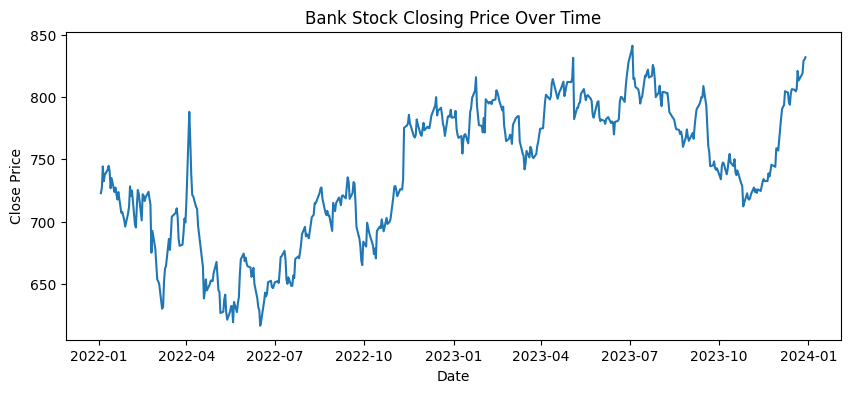

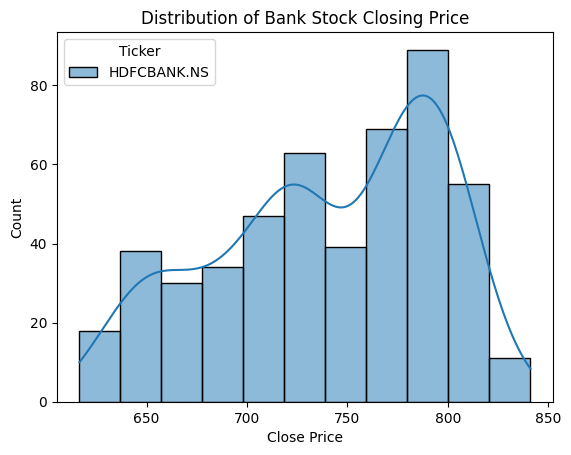

2026-01-31 08:35:14 +0000 - dagster - DEBUG - stock_ml_pipeline - b00c95d7-0138-4dba-b71c-8e8da1eb8cb3 - 703 - eda - STEP_OUTPUT - Yielded output "result" of type "Any". (Type check passed).
2026-01-31 08:35:14 +0000 - dagster - DEBUG - stock_ml_pipeline - b00c95d7-0138-4dba-b71c-8e8da1eb8cb3 - 703 - eda - HANDLED_OUTPUT - Handled output "result" using IO manager "io_manager"
2026-01-31 08:35:14 +0000 - dagster - DEBUG - stock_ml_pipeline - b00c95d7-0138-4dba-b71c-8e8da1eb8cb3 - 703 - eda - STEP_SUCCESS - Finished execution of step "eda" in 418ms.
2026-01-31 08:35:14 +0000 - dagster - DEBUG - stock_ml_pipeline - b00c95d7-0138-4dba-b71c-8e8da1eb8cb3 - 703 - feature_engineering - STEP_START - Started execution of step "feature_engineering".
2026-01-31 08:35:14 +0000 - dagster - DEBUG - stock_ml_pipeline - b00c95d7-0138-4dba-b71c-8e8da1eb8cb3 - 703 - feature_engineering - LOADED_INPUT - Loaded input "data" using input manager "io_manager", from output "result" of step "eda"
2026-01-31 08:

Decision Tree Accuracy: 0.6767676767676768
KNN Accuracy: 0.5858585858585859
Logistic Regression Accuracy: 0.8282828282828283


2026-01-31 08:35:14 +0000 - dagster - DEBUG - stock_ml_pipeline - b00c95d7-0138-4dba-b71c-8e8da1eb8cb3 - 703 - random_forest - STEP_OUTPUT - Yielded output "result" of type "Any". (Type check passed).
2026-01-31 08:35:14 +0000 - dagster - DEBUG - stock_ml_pipeline - b00c95d7-0138-4dba-b71c-8e8da1eb8cb3 - 703 - random_forest - HANDLED_OUTPUT - Handled output "result" using IO manager "io_manager"
2026-01-31 08:35:14 +0000 - dagster - DEBUG - stock_ml_pipeline - b00c95d7-0138-4dba-b71c-8e8da1eb8cb3 - 703 - random_forest - STEP_SUCCESS - Finished execution of step "random_forest" in 282ms.
/usr/local/lib/python3.12/dist-packages/dagster/_core/execution/context_creation_job.py:276: RuntimeWarning: coroutine 'BaseEventLoop.shutdown_asyncgens' was never awaited
  pass
2026-01-31 08:35:14 +0000 - dagster - DEBUG - stock_ml_pipeline - b00c95d7-0138-4dba-b71c-8e8da1eb8cb3 - 703 - ENGINE_EVENT - Finished steps in process (pid: 703) in 1.0s
2026-01-31 08:35:14 +0000 - dagster - DEBUG - stock_ml_p

Random Forest Accuracy: 0.6767676767676768


In [ ]:
stock_ml_pipeline.execute_in_process()
